In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
print("All libraries imported successfully!")
df = pd.read_csv('sales_data.csv')

All libraries imported successfully!


Dataset Shape: (730, 6)

First 5 rows:
        Date       Sales  Month  Year Month_Year  DayOfWeek
0 2021-01-01  304.967142      1  2021    2021-01          4
1 2021-01-02  304.922388      1  2021    2021-01          5
2 2021-01-03  318.862646      1  2021    2021-01          6
3 2021-01-04  333.259303      1  2021    2021-01          0
4 2021-01-05  320.701722      1  2021    2021-01          1

Data Types:
Date          datetime64[ns]
Sales                float64
Month                  int32
Year                   int32
Month_Year         period[M]
DayOfWeek              int32
dtype: object

Missing Values:
Date          0
Sales         0
Month         0
Year          0
Month_Year    0
DayOfWeek     0
dtype: int64


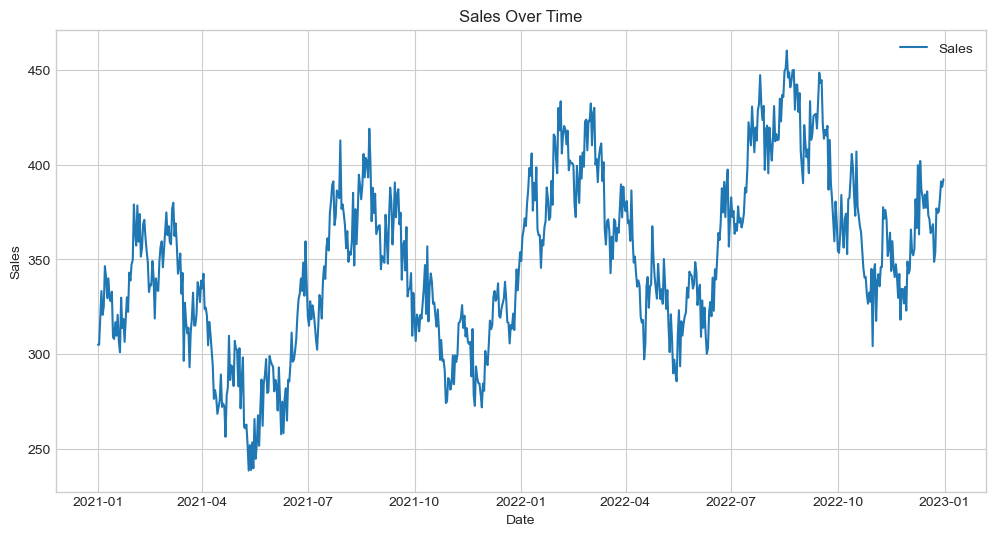

In [52]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date') # Ensure chronological order

# Visualize Sales
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Sales'], label='Sales')
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [29]:
np.random.seed(42)
n_days = 730 
dates = pd.date_range(start='2021-01-01', periods=n_days, freq='D')
trend = np.linspace(100, 200, n_days)  # Upward trend
seasonality = 50 * np.sin(np.linspace(0, 8*np.pi, n_days)) 
noise = np.random.normal(0, 10, n_days)  # Random noise
weekly_seasonality = 20 * np.sin(np.linspace(0, 52*np.pi, n_days)) 
sales = trend + seasonality + weekly_seasonality + noise + 200
df = pd.DataFrame({
    'Date': dates,
    'Sales': sales
})

print("DATASET OVERVIEW")

print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())
print(f"\nData Types:")
print(df.dtypes)
print(f"\nBasic Statistics:")
print(df.describe())

DATASET OVERVIEW

Dataset Shape: (730, 2)

First 5 rows:
        Date       Sales
0 2021-01-01  304.967142
1 2021-01-02  304.922388
2 2021-01-03  318.862646
3 2021-01-04  333.259303
4 2021-01-05  320.701722

Last 5 rows:
          Date       Sales
725 2022-12-27  375.116911
726 2022-12-28  382.155335
727 2022-12-29  391.090056
728 2022-12-30  388.297372
729 2022-12-31  392.216953

Data Types:
Date     datetime64[ns]
Sales           float64
dtype: object

Basic Statistics:
                      Date       Sales
count                  730  730.000000
mean   2021-12-31 12:00:00  349.859661
min    2021-01-01 00:00:00  238.523788
25%    2021-07-02 06:00:00  318.680642
50%    2021-12-31 12:00:00  347.947420
75%    2022-07-01 18:00:00  379.827022
max    2022-12-31 00:00:00  460.136611
std                    NaN   44.460590


MISSING VALUES CHECK

Missing Values:
Date     0
Sales    0
dtype: int64

Duplicate Rows: 0


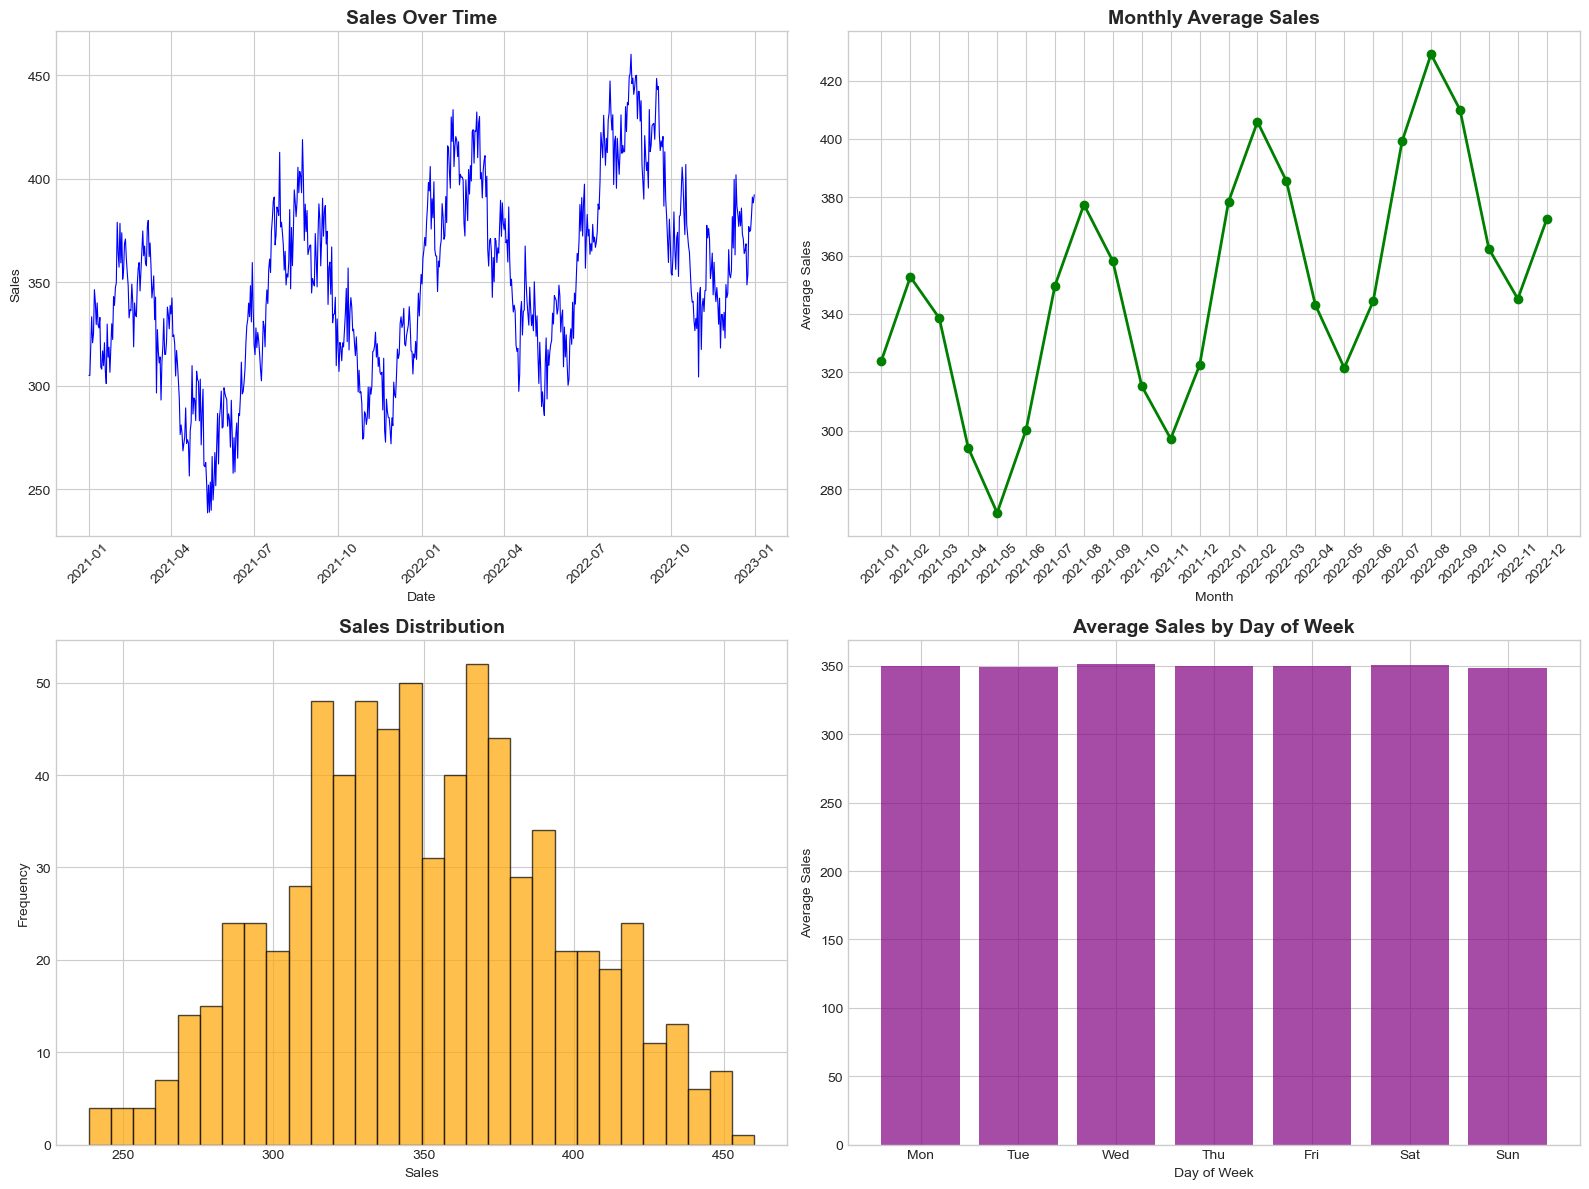


EDA completed! Check the visualizations above.


In [30]:
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing_values = df.isnull().sum()
print(f"\nMissing Values:\n{missing_values}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0, 0].plot(df['Date'], df['Sales'], color='blue', linewidth=0.8)
axes[0, 0].set_title('Sales Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Sales')
axes[0, 0].tick_params(axis='x', rotation=45)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month_Year'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month_Year')['Sales'].mean()
axes[0, 1].plot(monthly_sales.index.astype(str), monthly_sales.values, 
               marker='o', color='green', linewidth=2)
axes[0, 1].set_title('Monthly Average Sales', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Sales')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[1, 0].hist(df['Sales'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Sales Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Sales')
axes[1, 0].set_ylabel('Frequency')
df['DayOfWeek'] = df['Date'].dt.dayofweek
dow_sales = df.groupby('DayOfWeek')['Sales'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 1].bar(days, dow_sales.values, color='purple', alpha=0.7)
axes[1, 1].set_title('Average Sales by Day of Week', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Average Sales')
plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEDA completed! Check the visualizations above.")

In [32]:
# =============================================================================
# STEP 4: DATA PREPROCESSING
# =============================================================================

print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# Make a copy of original data
df_processed = df.copy()

# 4.1 Handle missing values
print("\n4.1 Handling Missing Values:")
if df_processed['Sales'].isnull().sum() > 0:
    # Fill missing values with forward fill
    df_processed['Sales'].fillna(method='ffill', inplace=True)
    print("Missing values filled using forward fill method")
else:
    print("No missing values found in Sales column")
print("\n4.2 Date Column Processing:")
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
print(f"Date column converted to datetime: {df_processed['Date'].dtype}")
print("\n4.3 Extracting Time-Based Features:")
df_processed['Year'] = df_processed['Date'].dt.year
df_processed['Month'] = df_processed['Date'].dt.month
df_processed['Day'] = df_processed['Date'].dt.day
df_processed['DayOfWeek'] = df_processed['Date'].dt.dayofweek
df_processed['WeekOfYear'] = df_processed['Date'].dt.isocalendar().week
df_processed['Quarter'] = df_processed['Date'].dt.quarter
df_processed['IsWeekend'] = df_processed['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df_processed['DayOfYear'] = df_processed['Date'].dt.dayofyear
print(f"Features extracted: Year, Month, Day, DayOfWeek, WeekOfYear, Quarter, IsWeekend, DayOfYear")
print("\n4.4 Creating Lag Features:")
for lag in [1, 7, 14, 30]:
    df_processed[f'Sales_Lag_{lag}'] = df_processed['Sales'].shift(lag)
    print(f"Created Sales_Lag_{lag}")
print("\n4.5 Creating Rolling Window Features:")
for window in [7, 14, 30]:
    df_processed[f'Sales_Rolling_Mean_{window}'] = df_processed['Sales'].shift(1).rolling(window=window).mean()
    df_processed[f'Sales_Rolling_Std_{window}'] = df_processed['Sales'].shift(1).rolling(window=window).std()
    print(f"Created Rolling_Mean_{window} and Rolling_Std_{window}")
df_processed = df_processed.dropna()
print(f"\nAfter dropping NaN rows, dataset shape: {df_processed.shape}")

print(f"\nProcessed Dataset Preview:")
print(df_processed.head())

DATA PREPROCESSING

4.1 Handling Missing Values:
No missing values found in Sales column

4.2 Date Column Processing:
Date column converted to datetime: datetime64[ns]

4.3 Extracting Time-Based Features:
Features extracted: Year, Month, Day, DayOfWeek, WeekOfYear, Quarter, IsWeekend, DayOfYear

4.4 Creating Lag Features:
Created Sales_Lag_1
Created Sales_Lag_7
Created Sales_Lag_14
Created Sales_Lag_30

4.5 Creating Rolling Window Features:
Created Rolling_Mean_7 and Rolling_Std_7
Created Rolling_Mean_14 and Rolling_Std_14
Created Rolling_Mean_30 and Rolling_Std_30

After dropping NaN rows, dataset shape: (700, 21)

Processed Dataset Preview:
         Date       Sales  Month  Year Month_Year  DayOfWeek  Day  WeekOfYear  \
30 2021-01-31  349.583518      1  2021    2021-01          6   31           4   
31 2021-02-01  378.925061      2  2021    2021-02          0    1           5   
32 2021-02-02  364.400822      2  2021    2021-02          1    2           5   
33 2021-02-03  357.263391

TIME SERIES DECOMPOSITION


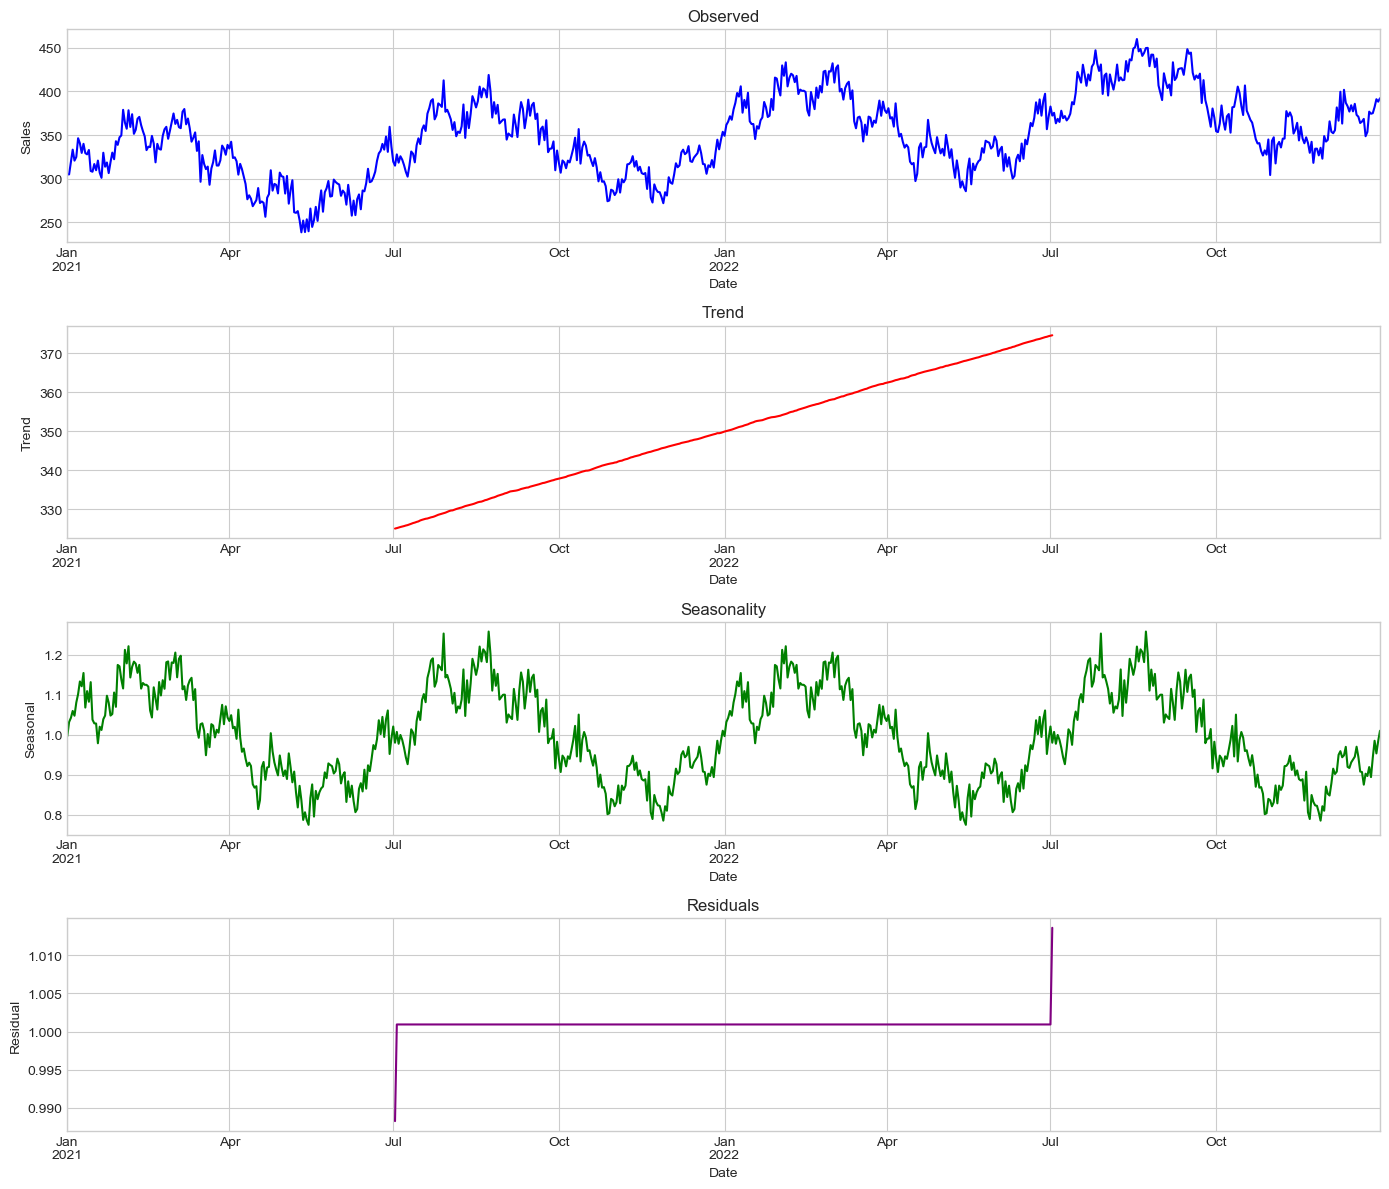


Stationarity Test (Augmented Dickey-Fuller):
ADF Statistic: -1.4291
p-value: 0.5682
Critical Values:
   1%: -3.4396
   5%: -2.8656
   10%: -2.5689

Result: The time series is NOT stationary (p-value >= 0.05)


In [33]:
print("=" * 60)
print("TIME SERIES DECOMPOSITION")
print("=" * 60)
df_ts = df.set_index('Date')['Sales']
decomposition = seasonal_decompose(df_ts, model='multiplicative', period=365)
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed', color='blue')
axes[0].set_ylabel('Sales')

decomposition.trend.plot(ax=axes[1], title='Trend', color='red')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], title='Residuals', color='purple')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('time_series_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nStationarity Test (Augmented Dickey-Fuller):")
adf_result = adfuller(df_ts)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nResult: The time series is stationary (p-value < 0.05)")
else:
    print("\nResult: The time series is NOT stationary (p-value >= 0.05)")

In [38]:
print("PREPARING DATA FOR MODELING")
df_model = df_processed.copy()
feature_columns = ['Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'Quarter', 
                   'IsWeekend', 'DayOfYear', 'Sales_Lag_1', 'Sales_Lag_7', 
                   'Sales_Lag_14', 'Sales_Lag_30', 'Sales_Rolling_Mean_7', 
                   'Sales_Rolling_Mean_14', 'Sales_Rolling_Mean_30',
                   'Sales_Rolling_Std_7', 'Sales_Rolling_Std_14', 
                   'Sales_Rolling_Std_30']
df_model['Month_Sin'] = np.sin(2 * np.pi * df_model['Month']/12)
df_model['Month_Cos'] = np.cos(2 * np.pi * df_model['Month']/12)
df_model['DayOfWeek_Sin'] = np.sin(2 * np.pi * df_model['DayOfWeek']/7)
df_model['DayOfWeek_Cos'] = np.cos(2 * np.pi * df_model['DayOfWeek']/7)

feature_columns.extend(['Month_Sin', 'Month_Cos', 'DayOfWeek_Sin', 'DayOfWeek_Cos'])

X = df_model[feature_columns]
y = df_model['Sales']
train_size = len(X) - 30
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nFeatures used: {len(feature_columns)}")
print(f"Feature columns: {feature_columns}")

PREPARING DATA FOR MODELING

Training set size: 670
Testing set size: 30

Features used: 22
Feature columns: ['Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'DayOfYear', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Lag_30', 'Sales_Rolling_Mean_7', 'Sales_Rolling_Mean_14', 'Sales_Rolling_Mean_30', 'Sales_Rolling_Std_7', 'Sales_Rolling_Std_14', 'Sales_Rolling_Std_30', 'Month_Sin', 'Month_Cos', 'DayOfWeek_Sin', 'DayOfWeek_Cos']


In [39]:
print("=" * 60)
print("BUILDING AND TRAINING FORECASTING MODELS")
print("=" * 60)
models_dict = {}
results_dict = {}
print("\n" + "-" * 40)
print("MODEL 1: LINEAR REGRESSION")
print("-" * 40)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")
print(f"R² Score: {r2_lr:.4f}")

models_dict['Linear Regression'] = lr_model
results_dict['Linear Regression'] = {'RMSE': rmse_lr, 'MAE': mae_lr, 'R2': r2_lr, 'predictions': y_pred_lr}



BUILDING AND TRAINING FORECASTING MODELS

----------------------------------------
MODEL 1: LINEAR REGRESSION
----------------------------------------
RMSE: 13.09
MAE: 9.51
R² Score: 0.2111


In [40]:
print("MODEL 2: RANDOM FOREST REGRESSOR")


rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")

models_dict['Random Forest'] = rf_model
results_dict['Random Forest'] = {'RMSE': rmse_rf, 'MAE': mae_rf, 'R2': r2_rf, 'predictions': y_pred_rf}

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))



MODEL 2: RANDOM FOREST REGRESSOR
RMSE: 15.99
MAE: 10.88
R² Score: -0.1768

Top 10 Most Important Features:
                  Feature  Importance
8             Sales_Lag_1    0.850563
12   Sales_Rolling_Mean_7    0.073657
17   Sales_Rolling_Std_30    0.008969
2                     Day    0.007730
15    Sales_Rolling_Std_7    0.007500
14  Sales_Rolling_Mean_30    0.006233
16   Sales_Rolling_Std_14    0.006204
9             Sales_Lag_7    0.006172
13  Sales_Rolling_Mean_14    0.005520
10           Sales_Lag_14    0.005285


In [50]:
print("\n" + "-" * 40)
print("MODEL 3: GRADIENT BOOSTING REGRESSOR")
print("-" * 40)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"RMSE: {rmse_gb:.2f}")
print(f"MAE: {mae_gb:.2f}")
print(f"R² Score: {r2_gb:.4f}")

models_dict['Gradient Boosting'] = gb_model
results_dict['Gradient Boosting'] = {'RMSE': rmse_gb, 'MAE': mae_gb, 'R2': r2_gb, 'predictions': y_pred_gb}


----------------------------------------
MODEL 3: GRADIENT BOOSTING REGRESSOR
----------------------------------------
RMSE: 13.40
MAE: 9.38
R² Score: 0.1731
